# PID velocity tuning

Closed-loop velocity controller for the two rear motors. Setpoint in m/s, encoder feedback, PWM out at 100 Hz.

Gains were tuned by hand. Z-N closed loop didn't really work here: with Ki=Kd=0 the motor won't even start until Kp is high enough to beat static friction, so I never got a clean sustained oscillation to read Ku/Tu off. Went manual instead.

Setup:
- 660 ticks/rev (measured), wheel radius 0.0341 m
- control loop 100 Hz
- velocity feedback uses an EMA filter (alpha=0.2) computed once per loop, otherwise the encoder window gets stolen by the telemetry/comms tasks and the measurement goes to garbage

Final values: Kp=1500, Ki=6000, Kd=30. Validated at: 0.2 m/s | 0.5 m/s | 1.0 m/s.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
cols = ['tag','t_ms','L_ticks','R_ticks','L_mps','R_mps',
        'yaw','pitch','roll','lax','lay','laz','gx','gy','gz','accu']
df = pd.read_csv('step_response.csv', header=None, names=cols)

df['t'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0
df.head()

,tag,t_ms,L_ticks,R_ticks,L_mps,R_mps,yaw,pitch,roll,lax,lay,laz,gx,gy,gz,accu,t
0,TELEM,1060080,746030,746097,0.000,0.000,-0.05,-3.28,1.73,-0.051,0.016,-0.016,0.000,0.000,0.000,3,0.00
1,TELEM,1060100,746039,746106,0.056,0.049,-0.05,-3.28,1.73,-0.051,0.016,-0.016,0.000,0.000,0.000,3,0.02
2,TELEM,1060120,746062,746128,0.172,0.162,-0.05,-3.28,1.73,-0.051,0.016,-0.016,-0.035,-0.004,-0.002,3,0.04
3,TELEM,1060140,746090,746155,0.274,0.269,-0.05,-3.28,1.73,-0.051,0.016,-0.016,0.008,0.002,0.008,3,0.06
4,TELEM,1060160,746120,746184,0.345,0.336,-0.05,-3.28,1.73,-0.051,0.016,-0.016,0.014,0.002,0.002,3,0.08


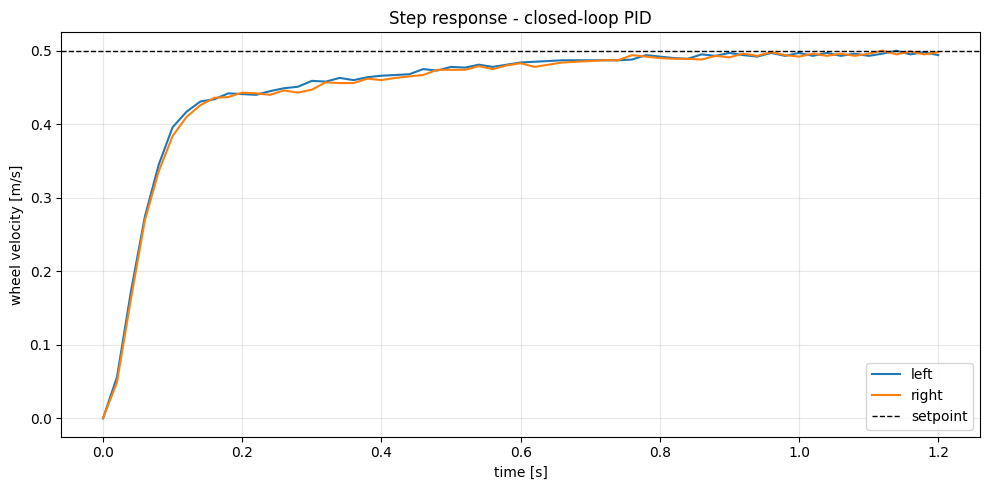

In [3]:
setpoint = 0.5

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['t'], df['L_mps'], label='left')
ax.plot(df['t'], df['R_mps'], label='right')
ax.axhline(setpoint, color='k', ls='--', lw=1, label='setpoint')
ax.set_xlabel('time [s]')
ax.set_ylabel('wheel velocity [m/s]')
ax.set_title('Step response - closed-loop PID')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('step_response.png', dpi=150)
plt.show()

In [4]:
# metrics off the left wheel
v = df['L_mps'].values
t = df['t'].values

t10 = t[np.argmax(v >= 0.1 * setpoint)]
t90 = t[np.argmax(v >= 0.9 * setpoint)]
rise = t90 - t10

peak = v.max()
overshoot = max(0.0, (peak - setpoint) / setpoint * 100)

band = 0.02 * setpoint
outside = np.abs(v - setpoint) > band
settle = t[np.where(outside)[0][-1]] if outside.any() else 0.0

ss_err = setpoint - v[-20:].mean()

print(f'rise time (10-90%): {rise*1000:.0f} ms')
print(f'overshoot:          {overshoot:.1f} %')
print(f'settling (2%):      {settle*1000:.0f} ms')
print(f'steady-state error: {ss_err*1000:.1f} mm/s')

rise time (10-90%): 260 ms
overshoot:          0.0 %
settling (2%):      840 ms
steady-state error: 5.4 mm/s
